[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_09/notebook_9_2_fairness_metrics.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 9.2: Fairness Metrics Implementation

**Chapter 9: Fairness and Bias in Healthcare AI**

## Learning Objectives

By the end of this notebook, you will be able to:
1. Implement core fairness metrics: demographic parity, equalized odds, equal opportunity, predictive parity
2. Understand mathematical relationships and impossibility theorems
3. Compute fairness metrics from confusion matrices
4. Visualize fairness-accuracy trade-offs
5. Choose appropriate fairness metrics for clinical contexts
6. Demonstrate that multiple fairness criteria cannot be simultaneously satisfied

## Clinical Context

**The challenge**: "Fairness" has no single definition. Different stakeholders prioritize different fairness criteria:

- **Patients**: Want equal likelihood of detecting their disease (equal sensitivity)
- **Healthcare systems**: Want predictions to be equally reliable across groups (predictive parity)
- **Policymakers**: Want equal access to beneficial interventions (demographic parity)
- **Clinicians**: Want equal quality of prediction (equalized odds)

**Key insight**: When disease prevalence differs across groups, these criteria **mathematically conflict**. We must choose which matters most.

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from typing import Dict, Tuple, List
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")
print("\nThis notebook implements formal fairness metrics for healthcare AI.")

Libraries imported successfully!

This notebook implements formal fairness metrics for healthcare AI.


## Part 1: Core Fairness Metrics - Mathematical Definitions

Let's define the four main fairness metrics mathematically:

**Notation**:
- $Y$: True label (1 = disease, 0 = no disease)
- $\hat{Y}$: Predicted label
- $A$: Protected attribute (e.g., race, sex)
- $a, b$: Different groups

### 1. Demographic Parity (Statistical Parity)
$$P(\hat{Y} = 1 | A = a) = P(\hat{Y} = 1 | A = b)$$
**Interpretation**: Same proportion flagged as positive across groups.

### 2. Equalized Odds
$$P(\hat{Y} = 1 | Y = y, A = a) = P(\hat{Y} = 1 | Y = y, A = b) \text{ for } y \in \{0, 1\}$$
**Interpretation**: Same TPR (sensitivity) AND same FPR across groups.

### 3. Equal Opportunity
$$P(\hat{Y} = 1 | Y = 1, A = a) = P(\hat{Y} = 1 | Y = 1, A = b)$$
**Interpretation**: Same TPR (sensitivity) across groups.

### 4. Predictive Parity (Calibration)
$$P(Y = 1 | \hat{Y} = 1, A = a) = P(Y = 1 | \hat{Y} = 1, A = b)$$
**Interpretation**: Same precision (PPV) across groups.

In [2]:
class FairnessMetrics:
    """
    Comprehensive fairness metrics calculator.

    Computes all major group fairness metrics from predictions.
    """

    def __init__(self, y_true, y_pred, groups):
        """
        Args:
            y_true: Ground truth labels (0/1)
            y_pred: Predicted labels (0/1)
            groups: Protected attribute (group membership)
        """
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)
        self.groups = np.array(groups)
        self.unique_groups = np.unique(groups)

        # Compute confusion matrices per group
        self.group_metrics = {}
        for group in self.unique_groups:
            mask = self.groups == group
            self.group_metrics[group] = self._compute_metrics(
                self.y_true[mask],
                self.y_pred[mask]
            )

    def _compute_metrics(self, y_true, y_pred):
        """Compute performance metrics from confusion matrix."""
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        n = len(y_true)
        n_positive = (y_true == 1).sum()
        n_negative = (y_true == 0).sum()

        # Rates
        tpr = tp / n_positive if n_positive > 0 else 0  # Sensitivity, Recall
        tnr = tn / n_negative if n_negative > 0 else 0  # Specificity
        fpr = fp / n_negative if n_negative > 0 else 0  # False positive rate
        fnr = fn / n_positive if n_positive > 0 else 0  # False negative rate

        # Predictive values
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision, PPV
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # NPV

        # Other metrics
        accuracy = (tp + tn) / n if n > 0 else 0
        selection_rate = (tp + fp) / n if n > 0 else 0  # Proportion flagged positive
        prevalence = n_positive / n if n > 0 else 0

        return {
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
            'tpr': tpr, 'tnr': tnr, 'fpr': fpr, 'fnr': fnr,
            'ppv': ppv, 'npv': npv,
            'accuracy': accuracy,
            'selection_rate': selection_rate,
            'prevalence': prevalence,
            'n': n
        }

    def demographic_parity(self) -> Dict:
        """
        Measure demographic parity: P(Ŷ=1|A=a) = P(Ŷ=1|A=b)

        Returns:
            Dict with selection rates and disparity
        """
        selection_rates = {g: self.group_metrics[g]['selection_rate']
                          for g in self.unique_groups}

        rates = list(selection_rates.values())
        disparity = max(rates) - min(rates)
        ratio = min(rates) / max(rates) if max(rates) > 0 else 1.0

        return {
            'selection_rates': selection_rates,
            'disparity': disparity,
            'ratio': ratio,
            'satisfied': disparity < 0.05  # Within 5 percentage points
        }

    def equalized_odds(self) -> Dict:
        """
        Measure equalized odds: TPR and FPR equal across groups.

        Returns:
            Dict with TPR/FPR per group and disparities
        """
        tprs = {g: self.group_metrics[g]['tpr'] for g in self.unique_groups}
        fprs = {g: self.group_metrics[g]['fpr'] for g in self.unique_groups}

        tpr_vals = list(tprs.values())
        fpr_vals = list(fprs.values())

        tpr_disparity = max(tpr_vals) - min(tpr_vals)
        fpr_disparity = max(fpr_vals) - min(fpr_vals)

        return {
            'tprs': tprs,
            'fprs': fprs,
            'tpr_disparity': tpr_disparity,
            'fpr_disparity': fpr_disparity,
            'satisfied': (tpr_disparity < 0.05 and fpr_disparity < 0.05)
        }

    def equal_opportunity(self) -> Dict:
        """
        Measure equal opportunity: TPR equal across groups.

        Returns:
            Dict with TPR per group and disparity
        """
        tprs = {g: self.group_metrics[g]['tpr'] for g in self.unique_groups}

        tpr_vals = list(tprs.values())
        disparity = max(tpr_vals) - min(tpr_vals)

        return {
            'tprs': tprs,
            'disparity': disparity,
            'satisfied': disparity < 0.05
        }

    def predictive_parity(self) -> Dict:
        """
        Measure predictive parity: PPV equal across groups.

        Returns:
            Dict with PPV per group and disparity
        """
        ppvs = {g: self.group_metrics[g]['ppv'] for g in self.unique_groups}

        ppv_vals = list(ppvs.values())
        disparity = max(ppv_vals) - min(ppv_vals)

        return {
            'ppvs': ppvs,
            'disparity': disparity,
            'satisfied': disparity < 0.05
        }

    def compute_all_metrics(self) -> pd.DataFrame:
        """
        Compute all fairness metrics and return as DataFrame.
        """
        results = []

        for group in self.unique_groups:
            m = self.group_metrics[group]
            results.append({
                'Group': group,
                'N': m['n'],
                'Prevalence': f"{m['prevalence']*100:.1f}%",
                'Selection Rate': f"{m['selection_rate']*100:.1f}%",
                'TPR (Sensitivity)': f"{m['tpr']*100:.1f}%",
                'FPR': f"{m['fpr']*100:.1f}%",
                'PPV (Precision)': f"{m['ppv']*100:.1f}%",
                'Accuracy': f"{m['accuracy']*100:.1f}%"
            })

        return pd.DataFrame(results)

    def summarize_fairness(self):
        """
        Print comprehensive fairness summary.
        """
        print("="*70)
        print("COMPREHENSIVE FAIRNESS EVALUATION")
        print("="*70)

        # Performance by group
        print("\nPerformance Metrics by Group:")
        print("-"*70)
        df = self.compute_all_metrics()
        display(df)

        # Fairness metrics
        print("\n" + "="*70)
        print("FAIRNESS METRICS EVALUATION")
        print("="*70)

        # 1. Demographic Parity
        dp = self.demographic_parity()
        print("\n1. DEMOGRAPHIC PARITY")
        print("   Definition: P(Ŷ=1|A=a) = P(Ŷ=1|A=b)")
        print("   Measures: Equal selection rates across groups")
        for group, rate in dp['selection_rates'].items():
            print(f"     {group}: {rate*100:.1f}% flagged positive")
        print(f"   Disparity: {dp['disparity']*100:.1f} percentage points")
        print(f"   Status: {'✓ SATISFIED' if dp['satisfied'] else '✗ VIOLATED'}")

        # 2. Equal Opportunity
        eo = self.equal_opportunity()
        print("\n2. EQUAL OPPORTUNITY")
        print("   Definition: P(Ŷ=1|Y=1,A=a) = P(Ŷ=1|Y=1,A=b)")
        print("   Measures: Equal TPR (sensitivity) across groups")
        for group, tpr in eo['tprs'].items():
            print(f"     {group}: {tpr*100:.1f}% sensitivity")
        print(f"   Disparity: {eo['disparity']*100:.1f} percentage points")
        print(f"   Status: {'✓ SATISFIED' if eo['satisfied'] else '✗ VIOLATED'}")

        # 3. Equalized Odds
        eqo = self.equalized_odds()
        print("\n3. EQUALIZED ODDS")
        print("   Definition: Equal TPR AND FPR across groups")
        print("   Measures: Equal error rates for both classes")
        print("   TPR disparity: {:.1f} pp".format(eqo['tpr_disparity']*100))
        print("   FPR disparity: {:.1f} pp".format(eqo['fpr_disparity']*100))
        print(f"   Status: {'✓ SATISFIED' if eqo['satisfied'] else '✗ VIOLATED'}")

        # 4. Predictive Parity
        pp = self.predictive_parity()
        print("\n4. PREDICTIVE PARITY")
        print("   Definition: P(Y=1|Ŷ=1,A=a) = P(Y=1|Ŷ=1,A=b)")
        print("   Measures: Equal PPV (precision) across groups")
        for group, ppv in pp['ppvs'].items():
            print(f"     {group}: {ppv*100:.1f}% precision")
        print(f"   Disparity: {pp['disparity']*100:.1f} percentage points")
        print(f"   Status: {'✓ SATISFIED' if pp['satisfied'] else '✗ VIOLATED'}")

        print("\n" + "="*70)

        # Summary
        satisfied_count = sum([
            dp['satisfied'],
            eo['satisfied'],
            eqo['satisfied'],
            pp['satisfied']
        ])

        print(f"\nSUMMARY: {satisfied_count}/4 fairness criteria satisfied")
        if satisfied_count == 4:
            print("✓ Model is fair by all measured criteria")
        elif satisfied_count >= 2:
            print("⚠️  Model satisfies some fairness criteria but not all")
        else:
            print("✗ Model violates most fairness criteria - mitigation needed")

        print("="*70)

print("✓ FairnessMetrics class defined")

✓ FairnessMetrics class defined


## Part 2: Simulated Classifier with Bias

Let's create a realistic scenario: melanoma classification with different performance across skin tones.

In [3]:
def simulate_biased_classifier(n_samples=5000, prevalence_light=0.03,
                              prevalence_dark=0.02):
    """
    Simulate melanoma classifier with realistic bias.

    Light skin: Higher sensitivity, lower FPR (model trained mostly on this)
    Dark skin: Lower sensitivity, similar FPR (underrepresented in training)
    """
    # Generate groups (70% light, 30% dark skin)
    groups = np.random.choice(['Light Skin', 'Dark Skin'], size=n_samples, p=[0.7, 0.3])

    y_true = []
    y_pred = []

    for group in groups:
        if group == 'Light Skin':
            # True label
            has_disease = np.random.random() < prevalence_light

            # Prediction (high sensitivity, low FPR)
            if has_disease:
                pred = np.random.random() < 0.92  # 92% sensitivity
            else:
                pred = np.random.random() < 0.08  # 8% FPR
        else:  # Dark Skin
            # True label
            has_disease = np.random.random() < prevalence_dark

            # Prediction (lower sensitivity, similar FPR)
            if has_disease:
                pred = np.random.random() < 0.75  # 75% sensitivity (17 pp lower!)
            else:
                pred = np.random.random() < 0.09  # 9% FPR

        y_true.append(int(has_disease))
        y_pred.append(int(pred))

    return np.array(y_true), np.array(y_pred), groups

# Generate data
print("Simulating biased melanoma classifier...\n")
y_true, y_pred, groups = simulate_biased_classifier(5000)

print(f"✓ Generated {len(y_true)} predictions")
print(f"  Light Skin: {(groups == 'Light Skin').sum()} ({(groups == 'Light Skin').mean()*100:.0f}%)")
print(f"  Dark Skin: {(groups == 'Dark Skin').sum()} ({(groups == 'Dark Skin').mean()*100:.0f}%)")
print(f"\n  Melanoma cases: {y_true.sum()} ({y_true.mean()*100:.1f}% prevalence)")
print(f"  Positive predictions: {y_pred.sum()} ({y_pred.mean()*100:.1f}%)")

Simulating biased melanoma classifier...

✓ Generated 5000 predictions
  Light Skin: 3530 (71%)
  Dark Skin: 1470 (29%)

  Melanoma cases: 119 (2.4% prevalence)
  Positive predictions: 531 (10.6%)


## Part 3: Computing Fairness Metrics

Now let's apply our fairness metrics to this biased classifier.

In [4]:
# Initialize fairness evaluator
fairness = FairnessMetrics(y_true, y_pred, groups)

# Compute and display all metrics
fairness.summarize_fairness()

COMPREHENSIVE FAIRNESS EVALUATION

Performance Metrics by Group:
----------------------------------------------------------------------


,Group,N,Prevalence,Selection Rate,TPR (Sensitivity),FPR,PPV (Precision),Accuracy
0,Dark Skin,1470,1.8%,11.6%,69.2%,10.6%,10.5%,89.0%
1,Light Skin,3530,2.6%,10.2%,97.8%,7.8%,25.3%,92.3%



FAIRNESS METRICS EVALUATION

1. DEMOGRAPHIC PARITY
   Definition: P(Ŷ=1|A=a) = P(Ŷ=1|A=b)
   Measures: Equal selection rates across groups
     Dark Skin: 11.6% flagged positive
     Light Skin: 10.2% flagged positive
   Disparity: 1.4 percentage points
   Status: ✓ SATISFIED

2. EQUAL OPPORTUNITY
   Definition: P(Ŷ=1|Y=1,A=a) = P(Ŷ=1|Y=1,A=b)
   Measures: Equal TPR (sensitivity) across groups
     Dark Skin: 69.2% sensitivity
     Light Skin: 97.8% sensitivity
   Disparity: 28.6 percentage points
   Status: ✗ VIOLATED

3. EQUALIZED ODDS
   Definition: Equal TPR AND FPR across groups
   Measures: Equal error rates for both classes
   TPR disparity: 28.6 pp
   FPR disparity: 2.8 pp
   Status: ✗ VIOLATED

4. PREDICTIVE PARITY
   Definition: P(Y=1|Ŷ=1,A=a) = P(Y=1|Ŷ=1,A=b)
   Measures: Equal PPV (precision) across groups
     Dark Skin: 10.5% precision
     Light Skin: 25.3% precision
   Disparity: 14.8 percentage points
   Status: ✗ VIOLATED


SUMMARY: 1/4 fairness criteria satisfied
✗ 

## Part 4: The Impossibility Theorem

**Key theoretical result**: When base rates (disease prevalence) differ across groups, it's **mathematically impossible** to simultaneously satisfy:
- Equalized odds (equal TPR and FPR)
- Predictive parity (equal PPV)
- Negative predictive parity (equal NPV)

Let's demonstrate this with synthetic data where we control prevalence.

In [5]:
def demonstrate_impossibility_theorem():
    """
    Demonstrate that satisfying multiple fairness criteria simultaneously
    is impossible when base rates differ.
    """
    print("="*70)
    print("DEMONSTRATING FAIRNESS IMPOSSIBILITY THEOREM")
    print("="*70)
    print("\nScenario: Perfect classifier with different prevalence across groups\n")

    n_per_group = 10000

    # Group A: 10% prevalence
    y_true_a = np.random.choice([0, 1], size=n_per_group, p=[0.9, 0.1])
    # Group B: 20% prevalence (2x higher)
    y_true_b = np.random.choice([0, 1], size=n_per_group, p=[0.8, 0.2])

    # Perfect classifier: predictions = ground truth
    y_pred_a = y_true_a.copy()
    y_pred_b = y_true_b.copy()

    # Combine
    y_true = np.concatenate([y_true_a, y_true_b])
    y_pred = np.concatenate([y_pred_a, y_pred_b])
    groups = np.array(['Group A (10% prevalence)']*n_per_group +
                     ['Group B (20% prevalence)']*n_per_group)

    # Evaluate
    fm = FairnessMetrics(y_true, y_pred, groups)

    # Check metrics
    eo = fm.equal_opportunity()
    pp = fm.predictive_parity()
    dp = fm.demographic_parity()

    print("PERFECT CLASSIFIER (100% TPR, 0% FPR for both groups):\n")
    print(f"1. Equal Opportunity (equal TPR):")
    for g, tpr in eo['tprs'].items():
        print(f"   {g:30s}: {tpr*100:.1f}% TPR")
    print(f"   Disparity: {eo['disparity']*100:.1f} pp")
    print(f"   Status: {'✓ SATISFIED' if eo['satisfied'] else '✗ VIOLATED'}")

    print(f"\n2. Predictive Parity (equal PPV):")
    for g, ppv in pp['ppvs'].items():
        print(f"   {g:30s}: {ppv*100:.1f}% PPV")
    print(f"   Disparity: {pp['disparity']*100:.1f} pp")
    print(f"   Status: {'✓ SATISFIED' if pp['satisfied'] else '✗ VIOLATED'}")

    print(f"\n3. Demographic Parity (equal selection rate):")
    for g, rate in dp['selection_rates'].items():
        print(f"   {g:30s}: {rate*100:.1f}% flagged positive")
    print(f"   Disparity: {dp['disparity']*100:.1f} pp")
    print(f"   Status: {'✓ SATISFIED' if dp['satisfied'] else '✗ VIOLATED'}")

    print("\n" + "-"*70)
    print("KEY INSIGHT:")
    print("-"*70)
    print("Even with a PERFECT classifier (equal TPR=100%, FPR=0%):")
    print("  ✓ Equal Opportunity is satisfied (equal TPR)")
    print("  ✗ Predictive Parity is VIOLATED (PPV differs due to prevalence)")
    print("  ✗ Demographic Parity is VIOLATED (selection rate = prevalence)")
    print("\nThis is MATHEMATICAL, not algorithmic!")
    print("When prevalence differs, you CANNOT satisfy all fairness criteria.")
    print("="*70)

# Run demonstration
demonstrate_impossibility_theorem()

DEMONSTRATING FAIRNESS IMPOSSIBILITY THEOREM

Scenario: Perfect classifier with different prevalence across groups

PERFECT CLASSIFIER (100% TPR, 0% FPR for both groups):

1. Equal Opportunity (equal TPR):
   Group A (10% prevalence)      : 100.0% TPR
   Group B (20% prevalence)      : 100.0% TPR
   Disparity: 0.0 pp
   Status: ✓ SATISFIED

2. Predictive Parity (equal PPV):
   Group A (10% prevalence)      : 100.0% PPV
   Group B (20% prevalence)      : 100.0% PPV
   Disparity: 0.0 pp
   Status: ✓ SATISFIED

3. Demographic Parity (equal selection rate):
   Group A (10% prevalence)      : 10.5% flagged positive
   Group B (20% prevalence)      : 19.5% flagged positive
   Disparity: 9.0 pp
   Status: ✗ VIOLATED

----------------------------------------------------------------------
KEY INSIGHT:
----------------------------------------------------------------------
Even with a PERFECT classifier (equal TPR=100%, FPR=0%):
  ✓ Equal Opportunity is satisfied (equal TPR)
  ✗ Predictive Parity

## Part 5: Visualizing Fairness Metrics

Visual comparison makes fairness violations immediately apparent.

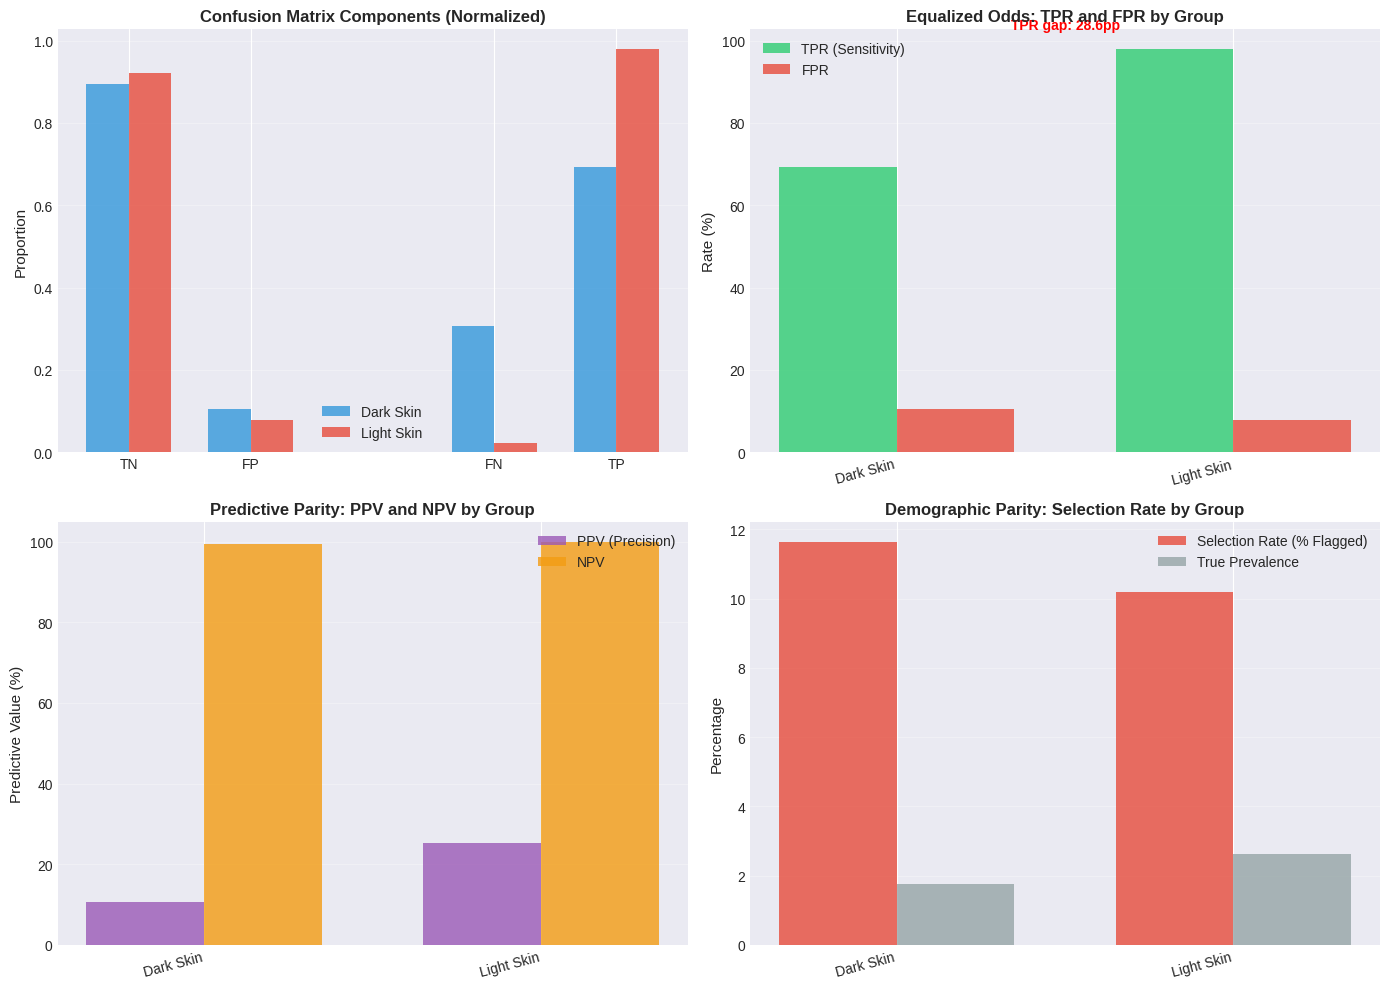


✓ Visualization saved as 'fairness_metrics_comparison.png'


In [6]:
def visualize_fairness_metrics(y_true, y_pred, groups):
    """
    Create comprehensive fairness visualizations.
    """
    fm = FairnessMetrics(y_true, y_pred, groups)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    unique_groups = np.unique(groups)
    colors = ['#3498db', '#e74c3c']

    # 1. Confusion matrices
    ax = axes[0, 0]
    for i, group in enumerate(unique_groups):
        m = fm.group_metrics[group]
        cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])

        # Normalize
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        # Plot as bars
        x = np.array([0, 1, 3, 4]) + i*0.35
        heights = [cm_norm[0,0], cm_norm[0,1], cm_norm[1,0], cm_norm[1,1]]
        ax.bar(x, heights, width=0.35, label=group, alpha=0.8, color=colors[i])

    ax.set_xticks([0.175, 1.175, 3.175, 4.175])
    ax.set_xticklabels(['TN', 'FP', 'FN', 'TP'])
    ax.set_ylabel('Proportion', fontsize=11)
    ax.set_title('Confusion Matrix Components (Normalized)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # 2. TPR and FPR comparison (Equalized Odds)
    ax = axes[0, 1]
    x_pos = np.arange(len(unique_groups))
    width = 0.35

    tprs = [fm.group_metrics[g]['tpr'] * 100 for g in unique_groups]
    fprs = [fm.group_metrics[g]['fpr'] * 100 for g in unique_groups]

    bars1 = ax.bar(x_pos - width/2, tprs, width, label='TPR (Sensitivity)',
                   color='#2ecc71', alpha=0.8)
    bars2 = ax.bar(x_pos + width/2, fprs, width, label='FPR',
                   color='#e74c3c', alpha=0.8)

    ax.set_ylabel('Rate (%)', fontsize=11)
    ax.set_title('Equalized Odds: TPR and FPR by Group', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(unique_groups, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Annotate disparity
    tpr_disparity = max(tprs) - min(tprs)
    ax.text(0.5, max(tprs) + 5, f"TPR gap: {tpr_disparity:.1f}pp",
           ha='center', fontsize=10, color='red', fontweight='bold')

    # 3. PPV comparison (Predictive Parity)
    ax = axes[1, 0]
    ppvs = [fm.group_metrics[g]['ppv'] * 100 for g in unique_groups]
    npvs = [fm.group_metrics[g]['npv'] * 100 for g in unique_groups]

    x_pos = np.arange(len(unique_groups))
    bars1 = ax.bar(x_pos - width/2, ppvs, width, label='PPV (Precision)',
                   color='#9b59b6', alpha=0.8)
    bars2 = ax.bar(x_pos + width/2, npvs, width, label='NPV',
                   color='#f39c12', alpha=0.8)

    ax.set_ylabel('Predictive Value (%)', fontsize=11)
    ax.set_title('Predictive Parity: PPV and NPV by Group', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(unique_groups, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # 4. Selection rates (Demographic Parity)
    ax = axes[1, 1]
    selection_rates = [fm.group_metrics[g]['selection_rate'] * 100 for g in unique_groups]
    prevalences = [fm.group_metrics[g]['prevalence'] * 100 for g in unique_groups]

    x_pos = np.arange(len(unique_groups))
    bars1 = ax.bar(x_pos - width/2, selection_rates, width,
                   label='Selection Rate (% Flagged)', color='#e74c3c', alpha=0.8)
    bars2 = ax.bar(x_pos + width/2, prevalences, width,
                   label='True Prevalence', color='#95a5a6', alpha=0.8)

    ax.set_ylabel('Percentage', fontsize=11)
    ax.set_title('Demographic Parity: Selection Rate by Group', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(unique_groups, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('fairness_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Visualization saved as 'fairness_metrics_comparison.png'")

# Create visualization
visualize_fairness_metrics(y_true, y_pred, groups)

## Part 6: Choosing Fairness Metrics for Clinical Context

**Different clinical scenarios prioritize different fairness criteria.**

Let's analyze three scenarios:

In [7]:
print("="*70)
print("CHOOSING FAIRNESS METRICS: CLINICAL CONTEXT MATTERS")
print("="*70)

scenarios = [
    {
        'name': 'Cancer Screening (Melanoma Detection)',
        'priority_metric': 'Equal Opportunity (TPR)',
        'rationale': [
            "Missing cancer is life-threatening",
            "Everyone deserves equal likelihood of early detection",
            "False positives lead to biopsy (invasive but not deadly)",
            "→ Prioritize equal SENSITIVITY across groups"
        ],
        'stakeholder': 'Patients and advocacy groups'
    },
    {
        'name': 'Resource Allocation (ICU Bed Assignment)',
        'priority_metric': 'Predictive Parity (PPV)',
        'rationale': [
            "ICU beds are scarce resources",
            "Predictions guide who gets admitted",
            "Need equal reliability: prediction should mean same thing for all",
            "→ Prioritize equal PRECISION across groups"
        ],
        'stakeholder': 'Hospital administrators'
    },
    {
        'name': 'Preventive Care Access (Diabetes Screening)',
        'priority_metric': 'Demographic Parity',
        'rationale': [
            "Screening access is a health equity issue",
            "Want equal opportunity for early intervention",
            "Policy goal: reduce disparities in access",
            "→ Prioritize equal SELECTION RATE across groups"
        ],
        'stakeholder': 'Public health policymakers'
    }
]

for i, scenario in enumerate(scenarios, 1):
    print(f"\n{'='*70}")
    print(f"SCENARIO {i}: {scenario['name']}")
    print("="*70)
    print(f"\nPriority Fairness Metric: {scenario['priority_metric']}")
    print(f"Key Stakeholder: {scenario['stakeholder']}")
    print(f"\nRationale:")
    for point in scenario['rationale']:
        print(f"  • {point}")

print("\n" + "="*70)
print("KEY LESSON")
print("="*70)
print("""
There is NO universal "correct" fairness metric.

Choice depends on:
  1. Clinical stakes (what harms are most severe?)
  2. Resource constraints (what is being allocated?)
  3. Stakeholder values (whose priorities matter?)
  4. Legal/policy context (what does anti-discrimination law require?)

BEST PRACTICE:
  → Measure MULTIPLE fairness metrics
  → Explicitly discuss trade-offs with stakeholders
  → Document which metric you prioritized and WHY
  → Monitor ALL metrics in deployment even if optimizing for one
""")
print("="*70)

CHOOSING FAIRNESS METRICS: CLINICAL CONTEXT MATTERS

SCENARIO 1: Cancer Screening (Melanoma Detection)

Priority Fairness Metric: Equal Opportunity (TPR)
Key Stakeholder: Patients and advocacy groups

Rationale:
  • Missing cancer is life-threatening
  • Everyone deserves equal likelihood of early detection
  • False positives lead to biopsy (invasive but not deadly)
  • → Prioritize equal SENSITIVITY across groups

SCENARIO 2: Resource Allocation (ICU Bed Assignment)

Priority Fairness Metric: Predictive Parity (PPV)
Key Stakeholder: Hospital administrators

Rationale:
  • ICU beds are scarce resources
  • Predictions guide who gets admitted
  • Need equal reliability: prediction should mean same thing for all
  • → Prioritize equal PRECISION across groups

SCENARIO 3: Preventive Care Access (Diabetes Screening)

Priority Fairness Metric: Demographic Parity
Key Stakeholder: Public health policymakers

Rationale:
  • Screening access is a health equity issue
  • Want equal opportunity 

## Key Takeaways

### Mathematical Definitions

1. **Demographic Parity**: P(Ŷ=1|A=a) = P(Ŷ=1|A=b)
   - Equal selection rates across groups
   - Distributive justice principle

2. **Equal Opportunity**: P(Ŷ=1|Y=1,A=a) = P(Ŷ=1|Y=1,A=b)  
   - Equal TPR (sensitivity) across groups
   - Everyone has equal chance of positive outcome detection

3. **Equalized Odds**: Equal TPR AND FPR across groups
   - Equal error rates for both classes
   - Comprehensive error equality

4. **Predictive Parity**: P(Y=1|Ŷ=1,A=a) = P(Y=1|Ŷ=1,A=b)
   - Equal PPV (precision) across groups
   - Predictions equally reliable

### Impossibility Theorem

**When base rates differ**, you CANNOT simultaneously satisfy:
- Equalized odds
- Predictive parity  
- Negative predictive parity

This is **mathematical**, not algorithmic. You must choose.

### Clinical Application

- **Cancer screening**: Prioritize equal opportunity (sensitivity)
- **Resource allocation**: Prioritize predictive parity (precision)
- **Access to care**: Prioritize demographic parity (selection rate)

### Best Practices

1. Compute ALL metrics, not just one
2. Understand trade-offs between metrics
3. Engage stakeholders in choosing priorities
4. Document fairness metric choice and rationale
5. Monitor continuously after deployment

---

## Exercises

1. **Manual calculation**: Given confusion matrices for two groups, compute all four fairness metrics by hand.

2. **Impossibility proof**: Mathematically prove that equal TPR, FPR, and PPV cannot be simultaneously achieved when prevalence differs.

3. **Threshold experiment**: For a probabilistic classifier, find thresholds that satisfy equal opportunity. Do they satisfy predictive parity?

4. **Stakeholder workshop**: Role-play a meeting with patients, clinicians, and administrators. Which fairness metric should a sepsis predictor optimize?

5. **Real-world analysis**: Find a healthcare AI paper claiming "fairness." Which metric did they use? Was it appropriate for the clinical context?

---

*This notebook is part of "AI in Healthcare" (Volume 1, Chapter 9: Fairness and Bias)*  
*Next: Notebook 9.3 - Bias Mitigation Strategies*